In [1]:
#import libraries
import pandas as pd
import numpy as np
import copy 
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

## PART 1: Data Collection 
The dataset is imported from a CSV file containing Spotify song data.

In [2]:
#import the spotify dataset
data = pd.read_csv(r'C:\Users\hasme\OneDrive\Desktop\My files\7th Semester\Data Mining\spofity2\spotify_500_dataset.csv')

In [3]:
#check the first 5 rows of the dataset
data.head()

,Artist,Track,Album,Album_type,Genre,Views,Likes,Licensed,Stream,Most_playedon,Popularity_score,Views_Normalized,Likes_Normalized,Stream_Normalized
0,Coldplay,Yellow,Parachutes,album,Alternative Rock,"832,532,409","4,600,933",True,"1,483,622,308",Spotify,"2,320,755,650",0.140907,0.148189,0.438096
1,Coldplay,Viva La Vida,Viva La Vida or Death and All His Friends,album,Alternative Rock,"789,581,468","4,370,461",True,"1,325,575,712",Spotify,"2,119,527,641",0.133637,0.140766,0.391427
2,Coldplay,Sparks,Parachutes,album,Alternative Rock,"73,201,019","787,343",True,"475,353,044",Spotify,"549,341,406",0.012389,0.025359,0.140366
3,Coldplay,Something Just Like This,Memories...Do Not Open,album,Alternative Rock,"2,118,018,686","10,282,499",True,"2,030,825,694",Youtube,"4,159,126,879",0.358476,0.331183,0.599679
4,Coldplay,The Scientist,A Rush of Blood to the Head,album,Alternative Rock,"1,082,588,109","5,532,787",True,"1,465,980,600",Spotify,"2,554,101,496",0.183229,0.178202,0.432887


## PART 2: Data Cleaning

In [4]:
#Some numerical variables have commas which will provide errors later on. So we removed those
num_cols = ["Views", "Likes", "Stream", "Popularity_score"]

for col in num_cols:
    data[col] = data[col].str.replace(",", "") #remove the comma
    data[col] = pd.to_numeric(data[col], errors="coerce") #convert the value to numeric

data.head() #Rechecking the data

,Artist,Track,Album,Album_type,Genre,Views,Likes,Licensed,Stream,Most_playedon,Popularity_score,Views_Normalized,Likes_Normalized,Stream_Normalized
0,Coldplay,Yellow,Parachutes,album,Alternative Rock,832532409,4600933,True,1483622308,Spotify,2320755650,0.140907,0.148189,0.438096
1,Coldplay,Viva La Vida,Viva La Vida or Death and All His Friends,album,Alternative Rock,789581468,4370461,True,1325575712,Spotify,2119527641,0.133637,0.140766,0.391427
2,Coldplay,Sparks,Parachutes,album,Alternative Rock,73201019,787343,True,475353044,Spotify,549341406,0.012389,0.025359,0.140366
3,Coldplay,Something Just Like This,Memories...Do Not Open,album,Alternative Rock,2118018686,10282499,True,2030825694,Youtube,4159126879,0.358476,0.331183,0.599679
4,Coldplay,The Scientist,A Rush of Blood to the Head,album,Alternative Rock,1082588109,5532787,True,1465980600,Spotify,2554101496,0.183229,0.178202,0.432887


In [5]:
#Converting pandas series into a dataframe
data = pd.DataFrame(data)
#Make a copy of the dataframe and work with that instead so the original data is not changed
df = data.copy()

In [6]:
# Check missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Artist               0
Track                0
Album                0
Album_type           0
Genre                0
Views                0
Likes                0
Licensed             0
Stream               0
Most_playedon        0
Popularity_score     0
Views_Normalized     0
Likes_Normalized     0
Stream_Normalized    0
dtype: int64


## PART 3: Data Understanding

In [7]:
#checking the size of the dataframe
df.shape

(500, 14)

In [8]:
#Checking the data types of each variable
df.dtypes

Artist                object
Track                 object
Album                 object
Album_type            object
Genre                 object
Views                  int64
Likes                  int64
Licensed                bool
Stream                 int64
Most_playedon         object
Popularity_score       int64
Views_Normalized     float64
Likes_Normalized     float64
Stream_Normalized    float64
dtype: object

### Out of 14 variables 6 variables are text/categorical variables, 7 are numerical and 1 is boolean(true/false)

In [9]:
#Checking if there are any noisy data. Noisy data consists of values that wouldn't make sense for our variables.

#The .describe function provides purely descriptive information about the dataset.
#This information includes statistics that summarize the central tendency of the variable, their dispersion.
print(df.describe())
#The .describe function for categorical features provides information about number of the unique categories and the category with the most frequency.
cdf=df.select_dtypes(include=['object']).describe()
print(f'\n\n {cdf}')

#By studying the statistics for each of the variables, we are able to conclude that there isn't any noisy data.
#In the case of our variables, any negative number would have been unacceptable as a value.


              Views         Likes        Stream  Popularity_score  \
count  5.000000e+02  5.000000e+02  5.000000e+02      5.000000e+02   
mean   3.375133e+08  2.358270e+06  4.598268e+08      7.996984e+08   
std    6.825681e+08  4.191745e+06  6.176678e+08      1.208955e+09   
min    0.000000e+00  0.000000e+00  0.000000e+00      1.040000e+02   
25%    4.064665e+06  3.799200e+04  2.800219e+07      4.227095e+07   
50%    4.068661e+07  3.502730e+05  1.259903e+08      2.110561e+08   
75%    3.101481e+08  2.949048e+06  7.619691e+08      1.150239e+09   
max    5.908398e+09  3.104778e+07  3.386520e+09      9.301451e+09   

       Views_Normalized  Likes_Normalized  Stream_Normalized  
count        500.000000        500.000000         500.000000  
mean           0.057124          0.075956           0.135782  
std            0.115525          0.135009           0.182390  
min            0.000000          0.000000           0.000000  
25%            0.000688          0.001224           0.008269  


In [10]:
#Understanding variables:
# Displaying the size, mean, min, and max for each numerical variable, grouped by the categorical variables(album type, genre and most played on)

df.select_dtypes(include='number').groupby([df['Most_playedon'], df['Genre'], df['Album_type']]).agg(['size','mean','min','max'])

Views                            \
                                            size          mean         min   
Most_playedon Genre            Album_type                                    
Spotify       Alternative Pop  album           4  5.966131e+08    49554662   
                               single          6  4.058527e+08    10608231   
              Alternative Rock album          15  6.114949e+08    63595971   
              Hip-Hop          album          26  4.240388e+08       36803   
              Pop              album         248  1.479114e+08           0   
                               compilation     8  1.073020e+07       80755   
                               single         63  6.826178e+07           0   
              Pop Rock         album           8  4.345539e+08          26   
              R&B              album           9  5.680125e+08     2024476   
              Reggaeton        album           1  3.188811e+06     3188811   
Youtube       Alternative Rock album           5  1.983728e+09  1665814269   
              Hip-Hop          album           4  1.577725e+09   454015875   
              Metal            album           1  4.261257e+08   426125708   
              Pop              album          79  8.239950e+08         103   
                               compilation     6  2.727178e+08      131403   
                               single         14  2.800883e+08     1670846   
              Pop Rock         album           2  2.417411e+09  1017088339   
              R&B              album           1  1.933921e+09  1933920747   

                                                       Likes                \
                                                   max  size          mean   
Most_playedon Genre            Album_type                                    
Spotify       Alternative Pop  album        1224659786     4  9.436989e+06   
                               single       1721400523     6  5.931763e+06   
              Alternative Rock album        1426556409    15  4.714507e+06   
              Hip-Hop          album        1977389041    26  3.853679e+06   
              Pop              album        1515227230   248  1.268974e+06   
                               compilation    41167375     8  1.214034e+05   
                               single        864857344    63  7.977154e+05   
              Pop Rock         album         901829354     8  3.225776e+06   
              R&B              album        2168809930     9  4.141798e+06   
              Reggaeton        album           3188811     1  3.837000e+04   
Youtube       Alternative Rock album        2369714846     5  1.294295e+07   
              Hip-Hop          album        2539156924     4  9.515754e+06   
              Metal            album         426125708     1  1.781690e+06   
              Pop              album        5908398479    79  4.274311e+06   
                               compilation   694614010     6  2.165626e+06   
                               single       2626029906    14  1.365778e+06   
              Pop Rock         album        3817733132     2  9.852054e+06   
              R&B              album        1933920747     1  1.178069e+07   

                                                               Stream  \
                                                 min       max   size   
Most_playedon Genre            Album_type                               
Spotify       Alternative Pop  album          992263  17920724      4   
                               single         191574  24426202      6   
              Alternative Rock album          787343   9256200     15   
              Hip-Hop          album             627  15244903     26   
              Pop              album               0  19846114    248   
                               compilation       599    449880      8   
                               single              0   5305141     63   
              Pop Rock         albu

## Categorical data analysis

In [11]:
#For each text variable, finding the proportions for each category
Artist_count=df.Artist.value_counts(normalize=True)
Album_count=df.Album.value_counts(normalize=True)
Album_type_count=df.Album_type.value_counts(normalize=True)
Genre_count=df.Genre.value_counts(normalize=True)
Most_playedon_count=df.Most_playedon.value_counts(normalize=True)
Licensed_count=df.Licensed.value_counts(normalize=True)

# .value_counts() helps us understand how many values of a given variable there are in our dataset in percentages.
print(f'\n\n{Artist_count} \n\n{Album_count} \n\n{Album_type_count} \n\n{Genre_count} \n\n{Most_playedon_count} \n\n{Licensed_count}')



Coldplay          0.020
Ariana Grande     0.020
Eminem            0.020
Billie Eilish     0.020
Dua Lipa          0.020
                  ...  
Good Charlotte    0.002
Oruam             0.002
Sublime           0.002
ATEEZ             0.002
City Girls        0.002
Name: Artist, Length: 311, dtype: float64 

Midnights                         0.012
Her Loss                          0.010
The Eminem Show                   0.008
Teenage Dream                     0.008
Future Nostalgia                  0.008
                                  ...  
Three Cheers for Sweet Revenge    0.002
Saiya Davatare                    0.002
The Heist                         0.002
Santo Pecado                      0.002
Still Over It                     0.002
Name: Album, Length: 423, dtype: float64 

album          0.806
single         0.166
compilation    0.028
Name: Album_type, dtype: float64 

Pop                 0.836
Hip-Hop             0.060
Alternative Rock    0.040
Pop Rock            0.020
R&B  

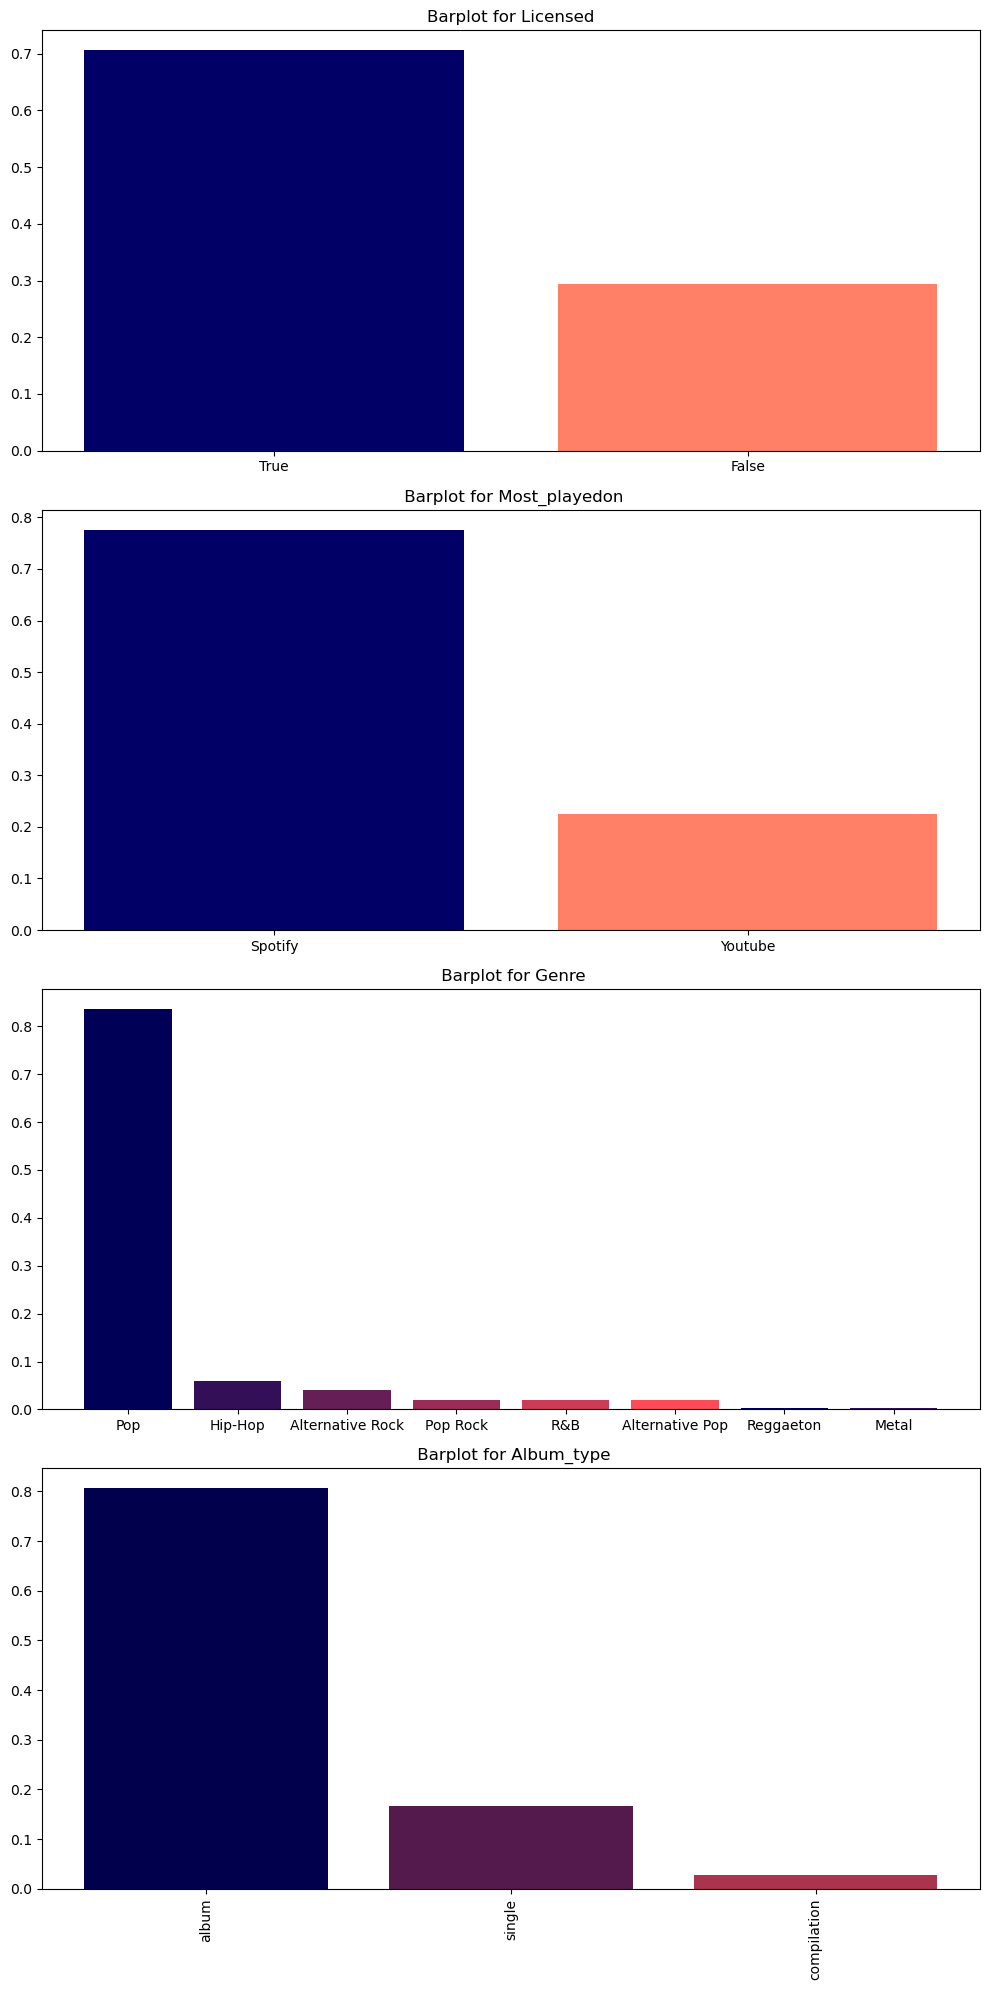

In [12]:
#Barplot for 4 of the categorical data
#It wouldn't be useful to create 

f, axs = plt.subplots(4,1, sharex=False, sharey=False,figsize=(10,20))

my_colors = [(x/1.0, x/2.0, 0.4) for x in range(0,2)]
# Barplot for Licensed variable
axs[0].bar(['True','False'], list(Licensed_count),color=my_colors)
axs[0].set_title("Barplot for Licensed")

amy_colors = [(x/3.0, x/10.0, 0.30) for x in range(0,2)]
# Barplot for Most_playedon variable
axs[1].bar(['Spotify','Youtube'], list(Most_playedon_count), color=my_colors)
axs[1].set_title(" Barplot for Most_playedon")

# Barplot for genre variable
my_colors = [(x/5.0, x/17.0, 0.34) for x in range(0,6)]
axs[2].bar(['Pop','Hip-Hop','Alternative Rock','Pop Rock','R&B','Alternative Pop', 'Reggaeton', 'Metal'],list(Genre_count), color=my_colors)
axs[2].set_title(" Barplot for Genre")

#Barplot for album type variable
my_colors = [(x/3.0, x/10.0, 0.30) for x in range(0,3)]
axs[3].bar(['album','single','compilation'], list(Album_type_count),color=my_colors)
axs[3].set_title(" Barplot for Album_type")
plt.xticks(rotation=90)

        

#f.suptitle('Categorical Plotting')
plt.tight_layout()
plt.show()

## PART 4: Data Reduction - Histogram Analysis

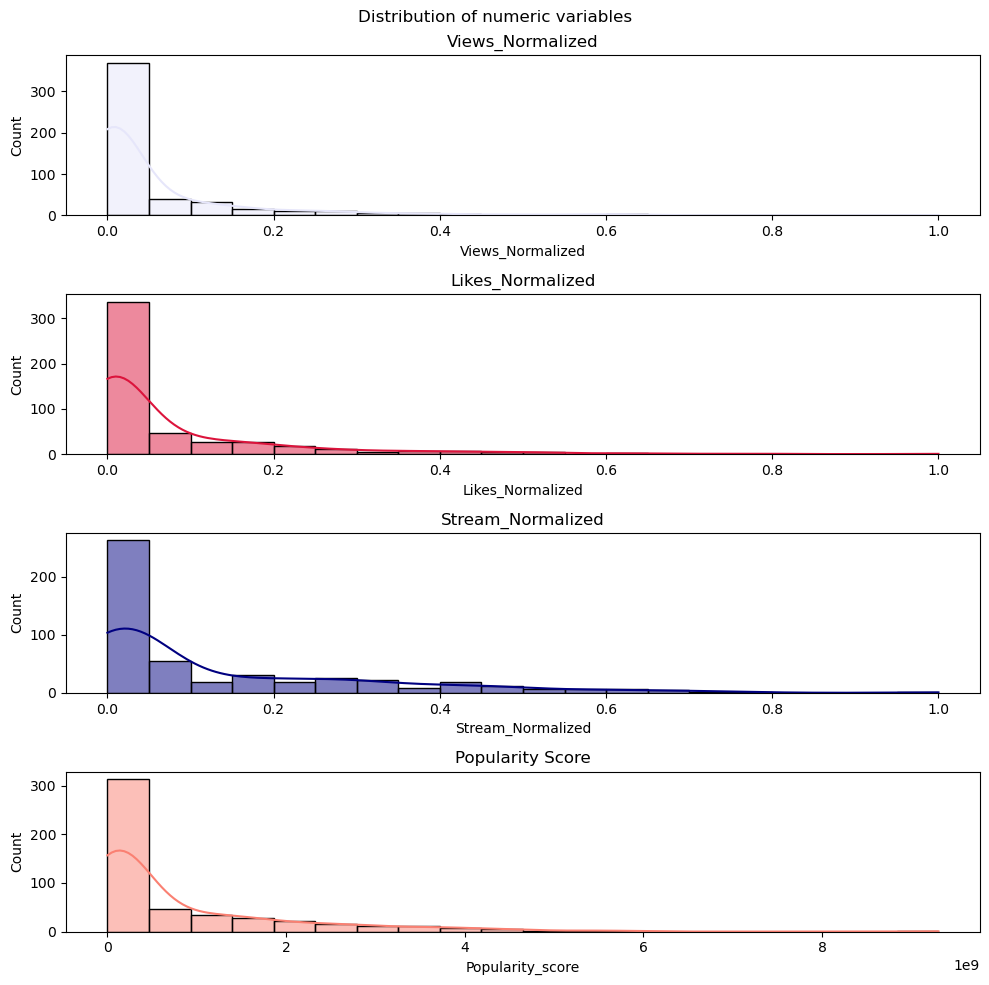

In [13]:
f, axs = plt.subplots(4, 1, sharex=False, sharey=False, figsize=(10,10))

sns.histplot(df["Views_Normalized"].dropna(), color='lavender', ax=axs[0], bins=20, kde=True)
axs[0].set_title("Views_Normalized")

sns.histplot(df["Likes_Normalized"].dropna(), color='crimson', ax=axs[1], bins=20, kde=True)
axs[1].set_title("Likes_Normalized")

sns.histplot(df["Stream_Normalized"].dropna(), color='navy', ax=axs[2], bins=20, kde=True)
axs[2].set_title("Stream_Normalized")

sns.histplot(df["Popularity_score"].dropna(), color='salmon', ax=axs[3], bins=20, kde=True)
axs[3].set_title("Popularity Score")

f.suptitle('Distribution of numeric variables')

plt.tight_layout()
plt.show()

## Data Reduction - Attribute Subset Selection

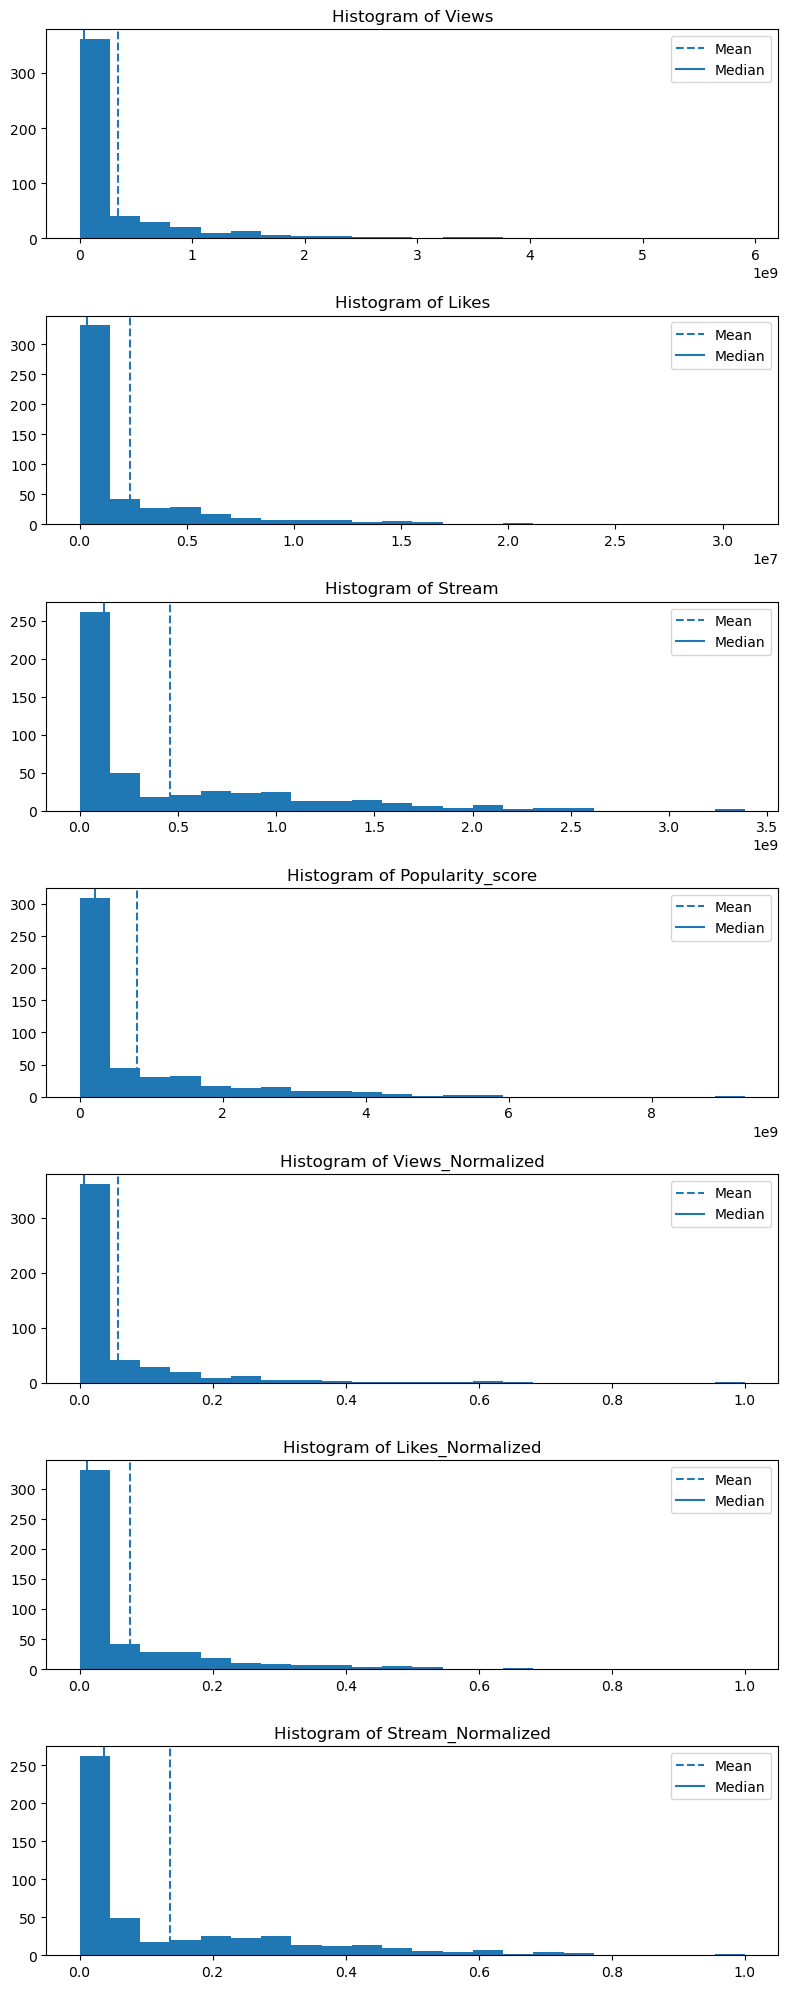

In [14]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(8, 20))

for i, col in enumerate(numeric_cols):

    data = df[col].dropna()
    bins = int(np.sqrt(len(data)))

    axs[i].hist(data, bins=bins)

    mean = data.mean()
    median = data.median()

    axs[i].axvline(mean, linestyle='dashed', label='Mean')
    axs[i].axvline(median, linestyle='solid', label='Median')

    axs[i].set_title(f'Histogram of {col}')
    axs[i].legend()

plt.tight_layout()
plt.show()

## PART 5: Data Transformation

ENCODING CATEGORICAL FEATURES
In order to deal only with categorical features, it's better to filter them out. 
There are 7 categorical features in our changed dataset:

Label Encoding: In this technique, each value of the categorical data is converted into an integer value. Numerical labels are always between 0 and n_categories-1. In our dataset there will be 3 features that will be encoded using this technique: licensed, most_playedon, album_type. 

In [15]:
#Convert licensed and Most_playedon variables into numerical variables

df["Licensed"] = df["Licensed"].astype(int)#true -1, false-0
df["Most_playedon"] = df["Most_playedon"].map({"Spotify":1, "Youtube":0})
df["Album_type"] = df["Album_type"].map({"album":2, "single":1, "compilation":0})
df["Genre"] = df["Genre"].map({"Pop":7, "Hip-Hop":6, "Alternative Rock":5, "Pop-Rock":4,"R&B":3,"Alternative Pop":2,"Reggaeton":1,"Metal":0})

df.head()

,Artist,Track,Album,Album_type,Genre,Views,Likes,Licensed,Stream,Most_playedon,Popularity_score,Views_Normalized,Likes_Normalized,Stream_Normalized
0,Coldplay,Yellow,Parachutes,2,5.0,832532409,4600933,1,1483622308,1,2320755650,0.140907,0.148189,0.438096
1,Coldplay,Viva La Vida,Viva La Vida or Death and All His Friends,2,5.0,789581468,4370461,1,1325575712,1,2119527641,0.133637,0.140766,0.391427
2,Coldplay,Sparks,Parachutes,2,5.0,73201019,787343,1,475353044,1,549341406,0.012389,0.025359,0.140366
3,Coldplay,Something Just Like This,Memories...Do Not Open,2,5.0,2118018686,10282499,1,2030825694,0,4159126879,0.358476,0.331183,0.599679
4,Coldplay,The Scientist,A Rush of Blood to the Head,2,5.0,1082588109,5532787,1,1465980600,1,2554101496,0.183229,0.178202,0.432887


## CORRELATION 
The correlation coefficient is a value that indicates the strength of the relationship between variables. The coefficient takes any value from -1 to 1.

-1: Perfect negative correlation. The variables tend to move in opposite directions (i.e., when one variable increases, the other variable decreases). 0: No correlation. The variables do not have a relationship with each other. 1: Perfect positive correlation. The variables tend to move in the same direction (i.e., when one variable increases, the other variable also increases).

A correlation matrix refers to these coefficients entered in tabular form, featuring the values for respective variables. The row-by-column arrangement of the coefficients helps to analyze the relationship between two or more variables and how they depend on each other.

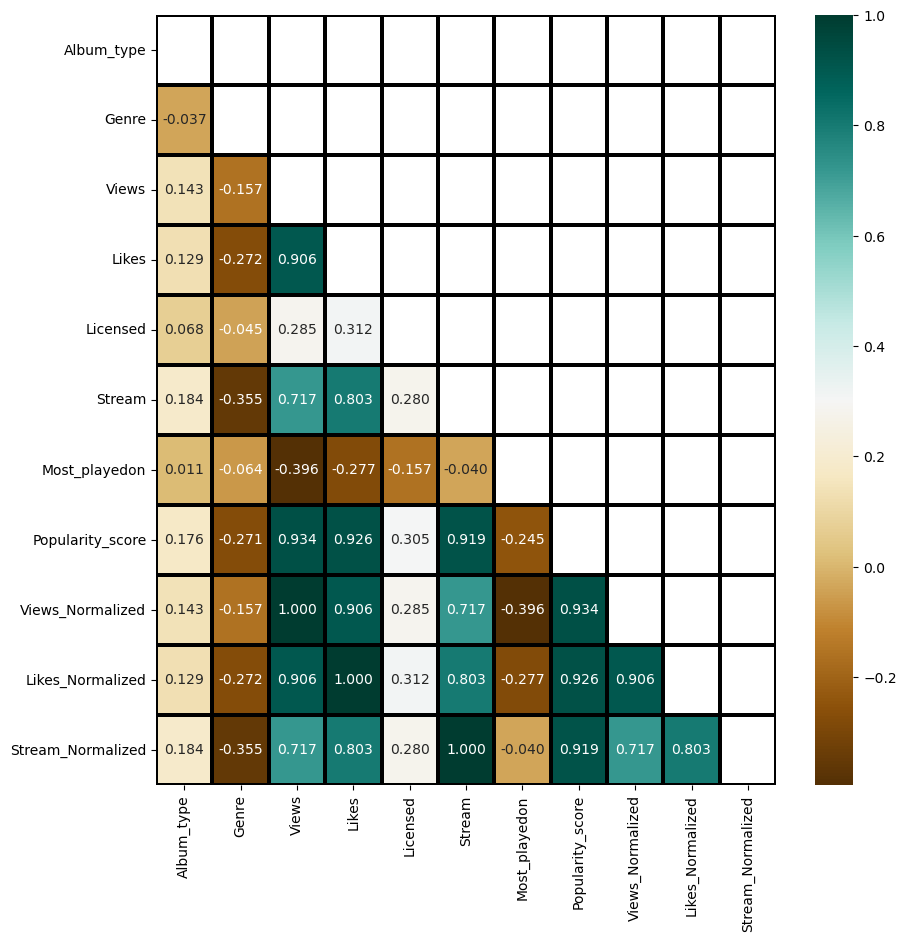

In [16]:
fig, ax = plt.subplots(figsize=(10,10))
corr = df.select_dtypes(include='number').corr()
ax=sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),cmap='BrBG',
            square=False, ax=ax,annot=True,linewidths=1.5,linecolor='k',cbar=True,fmt=".3f")

## PART 6: MODEL - CLUSTERING

K-Means clustering is used to group songs based on views, likes, streams, and album type. 

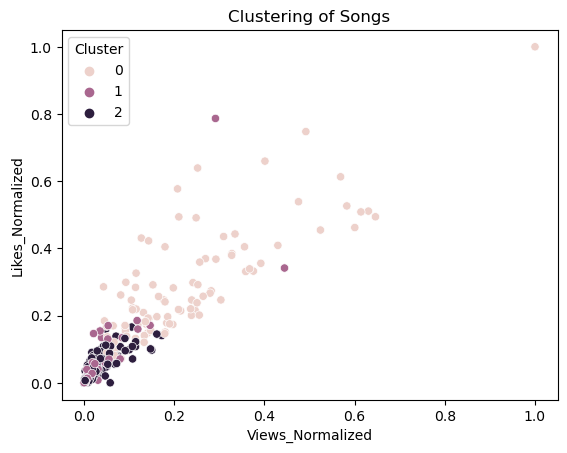

,Views_Normalized,Likes_Normalized,Stream_Normalized
Cluster,,,
0,0.218133,0.276283,0.431552
1,0.021600,0.039491,0.068527
2,0.015359,0.021515,0.059698


In [17]:
from sklearn.cluster import KMeans
features = ["Views_Normalized", "Likes_Normalized", "Stream_Normalized", "Album_type"]

X = df[["Views_Normalized", "Likes_Normalized", "Stream_Normalized", "Album_type"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)


sns.scatterplot(
    x="Views_Normalized",
    y="Likes_Normalized",
    hue="Cluster",
    data=df
)

plt.title("Clustering of Songs")
plt.show()

df.groupby("Cluster")[["Views_Normalized","Likes_Normalized","Stream_Normalized"]].mean()

In [18]:
#Importing libraries important in this phase
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split

## LINEAR REGRESSION

In [19]:
#Simple linear regression with only one predictor:
#The most correlated feature with the target variable likes was views
#This code builds a simple linear regression model using Scikit-learn to predict Likes based on Views.
#The code splits the dataset into training and testing sets, fits a linear regression model to predict Likes using Views, 
#generates predictions, and outputs the model’s coefficient and intercept to describe the relationship between the variables.

# Create linear regression object
regr = linear_model.LinearRegression()

#converting the predictor variable into an array and reshaping
x=np.array(df.Views).reshape(df.shape[0],1)
y= df.Likes
# Split the data
x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 0)
#Train the model
lr1 = regr.fit(x_train,y_train)
#Make predictions
y1_train_pred = lr1.predict(x_train)
y1_test_pred = lr1.predict(x_test)

# The coefficients and the intercept
# Get model parameters
#Coefficient (slope): how much Likes change when Views increase
#Intercept: predicted Likes when Views = 0
coeff1= [round(el,2) for el in regr.coef_]
intercept1= round(regr.intercept_,2)
print(f'The coefficients are:\n {coeff1} \n\n\nThe intercept point is:{intercept1} \n\n' )

The coefficients are:
 [0.01] 


The intercept point is:456888.48 




# Interpretation of the coefficient and intercept

## Coefficient (0.01):
This means that for every 1 unit increase in Views, the number of Likes increases by 0.01 on average.
+100 views → +1 like
+1,000 views → +10 likes

## Intercept (456,888.48):
This is the predicted number of Likes when Views = 0.
While mathematically necessary, this value is often not meaningful in real life, since a song with 0 views wouldn’t realistically have likes.

## Final Regression Formula
## Likes = 0.01 × Views + 456,888.48

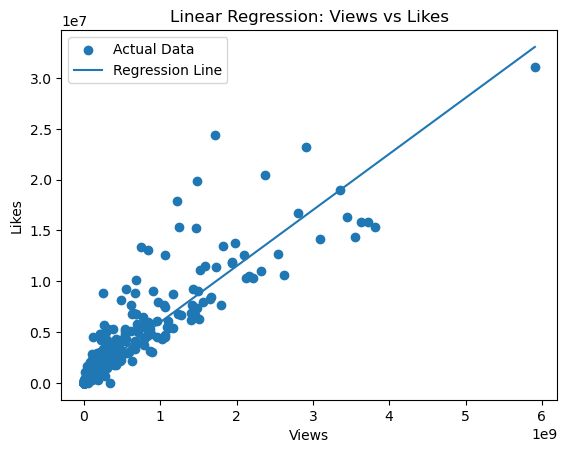

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Sort values for a clean line
sorted_idx = np.argsort(x.flatten())
x_sorted = x.flatten()[sorted_idx]
y_pred_sorted = lr1.predict(x.reshape(-1,1))[sorted_idx]

plt.scatter(x, y, label="Actual Data")
plt.plot(x_sorted, y_pred_sorted, label="Regression Line")

plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Linear Regression: Views vs Likes")

plt.legend()
plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Artist             500 non-null    object 
 1   Track              500 non-null    object 
 2   Album              500 non-null    object 
 3   Album_type         500 non-null    int64  
 4   Genre              490 non-null    float64
 5   Views              500 non-null    int64  
 6   Likes              500 non-null    int64  
 7   Licensed           500 non-null    int32  
 8   Stream             500 non-null    int64  
 9   Most_playedon      500 non-null    int64  
 10  Popularity_score   500 non-null    int64  
 11  Views_Normalized   500 non-null    float64
 12  Likes_Normalized   500 non-null    float64
 13  Stream_Normalized  500 non-null    float64
 14  Cluster            500 non-null    int32  
dtypes: float64(4), int32(2), int64(6), object(3)
memory usage: 54.8+ KB


## PART 7: MODEL - CLASSIFICATION 

A new feature, Engagement_Score, was created as (Likes + Streams)/Views to measure user interaction relative to exposure. This helps capture engagement quality rather than raw popularity. The score was then categorized into Low, Medium, and High engagement levels, making the data easier to interpret and suitable for classification models and pattern analysis.

In [22]:
import numpy as np

# Create engagement score safely
df['Engagement_Score'] = np.where(
    df['Views'] == 0,
    0,
    (0.3 * df['Likes'] + 0.7 * df['Stream']) / df['Views']
)


In [23]:
#Classify engagement levels as low, medium and high

low_thresh = df['Engagement_Score'].quantile(0.33)
high_thresh = df['Engagement_Score'].quantile(0.66)

df['Engagement_Level'] = np.where(
    df['Engagement_Score'] >= high_thresh, 'High',
    np.where(df['Engagement_Score'] >= low_thresh, 'Medium', 'Low')
)

In [24]:
df

,Artist,Track,Album,Album_type,Genre,Views,Likes,Licensed,Stream,Most_playedon,Popularity_score,Views_Normalized,Likes_Normalized,Stream_Normalized,Cluster,Engagement_Score,Engagement_Level
0,Coldplay,Yellow,Parachutes,2,5.0,832532409,4600933,1,1483622308,1,2320755650,0.140907,0.148189,0.438096,0,1.249100,Medium
1,Coldplay,Viva La Vida,Viva La Vida or Death and All His Friends,2,5.0,789581468,4370461,1,1325575712,1,2119527641,0.133637,0.140766,0.391427,0,1.176844,Medium
2,Coldplay,Sparks,Parachutes,2,5.0,73201019,787343,1,475353044,1,549341406,0.012389,0.025359,0.140366,2,4.548889,High
3,Coldplay,Something Just Like This,Memories...Do Not Open,2,5.0,2118018686,10282499,1,2030825694,0,4159126879,0.358476,0.331183,0.599679,0,0.672639,Low
4,Coldplay,The Scientist,A Rush of Blood to the Head,2,5.0,1082588109,5532787,1,1465980600,1,2554101496,0.183229,0.178202,0.432887,0,0.949434,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Lil Peep,Star Shopping,Star Shopping,1,7.0,86499,3856,0,798993758,1,799084113,0.000015,0.000124,0.235934,1,6465.933565,High
496,Los Prisioneros,La Voz de los '80,La Voz de los '80 (Edición 30 Años),2,7.0,42809,580,0,24364820,1,24408209,0.000007,0.000019,0.007195,2,398.410334,High
497,Clean Bandit,Drive (feat. Wes Nelson),Drive (feat. Wes Nelson),1,7.0,19939648,141191,1,107544414,1,127625253,0.003375,0.004548,0.031757,1,3.777572,High
498,Theory of a Deadman,Dinosaur,Dinosaur,1,7.0,391480,6817,1,1432119,1,1830416,0.000066,0.000220,0.000423,1,2.565976,Medium
